<a href="https://colab.research.google.com/github/Shambhuraje1919/Machine_Learning_Paractice/blob/main/Outlier_Capping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("/content/placement.csv")

In [3]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


/tmp/ipykernel_6078/4260214945.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
/tmp/ipykernel_6078/4260214945.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


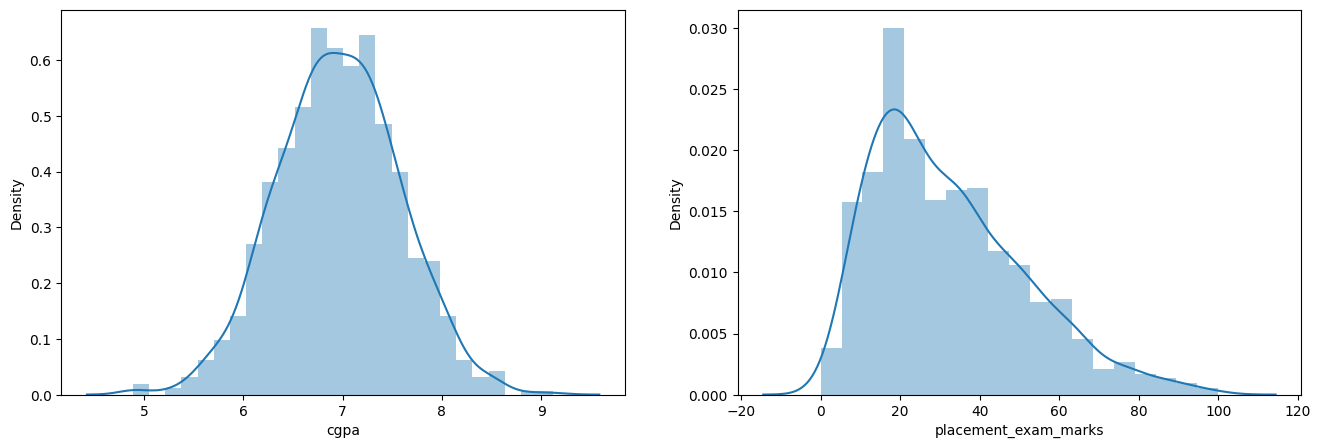

In [26]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])
plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])
plt.show()

In [27]:
df['placement_exam_marks'].describe()

,placement_exam_marks
count,1000.000000
mean,32.225000
std,19.130822
min,0.000000
25%,17.000000
50%,28.000000
75%,44.000000
max,100.000000


In [30]:
df['cgpa'].describe()

,cgpa
count,1000.000000
mean,6.961240
std,0.615898
min,4.890000
25%,6.550000
50%,6.960000
75%,7.370000
max,9.120000


<Axes: ylabel='placement_exam_marks'>

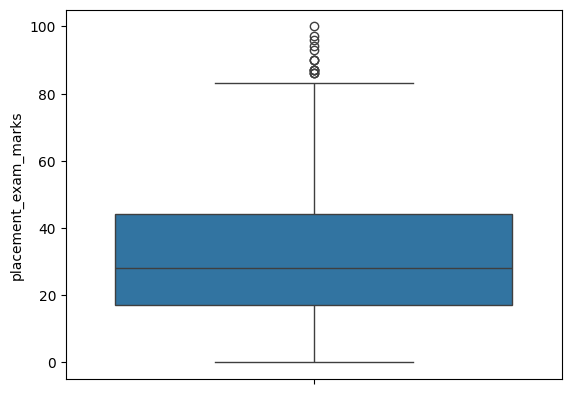

In [33]:
sns.boxplot(df['placement_exam_marks'])

<Axes: ylabel='cgpa'>

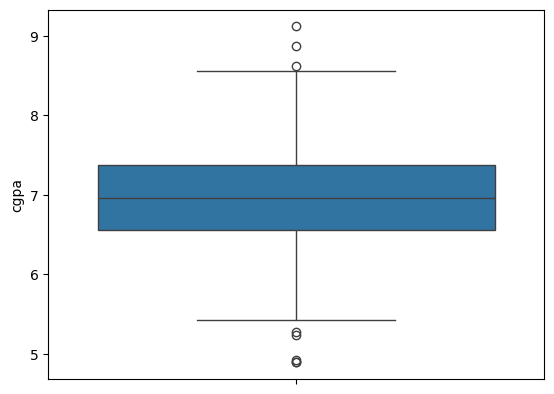

In [35]:
sns.boxplot(df['cgpa'])

In [45]:
q1 = df['placement_exam_marks'].quantile(0.25)
q3 = df['placement_exam_marks'].quantile(0.75)
print(q1)
print(q3)

17.0
44.0


In [46]:
iqr = q3-q1

In [47]:
iqr

np.float64(27.0)

In [48]:
upper = q3+1.5*iqr
lower = q1-1.5*iqr

In [49]:
upper

np.float64(84.5)

In [50]:
lower

np.float64(-23.5)

In [53]:
new_df =df[(df['placement_exam_marks']<upper)& (df['placement_exam_marks']>lower)]

In [54]:
new_df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


<Axes: ylabel='placement_exam_marks'>

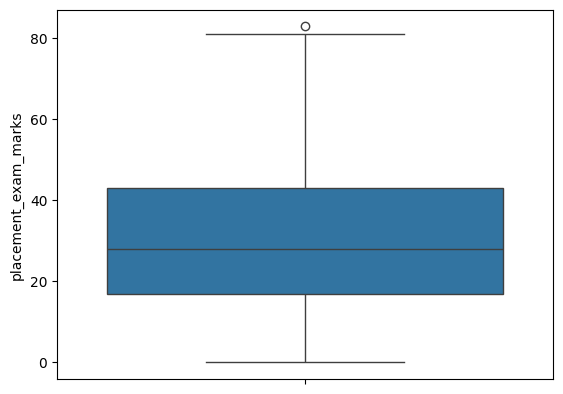

In [56]:
sns.boxplot(new_df['placement_exam_marks'])

In [57]:
new_df[new_df['placement_exam_marks']>upper]

,cgpa,placement_exam_marks,placed


In [58]:
new_df[new_df['placement_exam_marks']<lower]

,cgpa,placement_exam_marks,placed


In [63]:
df_cap = df.copy()
df_cap["placement_exam_marks"] = np.where(df['placement_exam_marks']>upper,upper,
                  np.where(df['placement_exam_marks']<lower,lower,
                  df['placement_exam_marks']))


<Axes: ylabel='placement_exam_marks'>

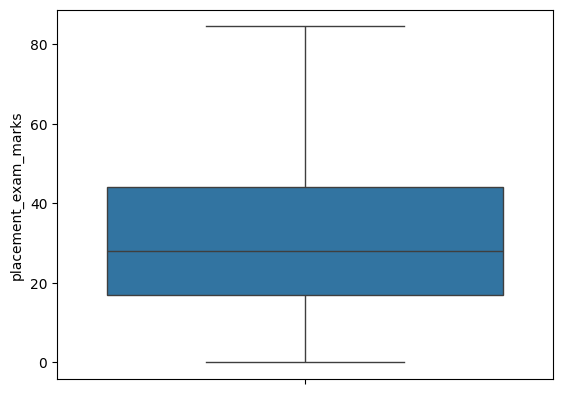

In [65]:
sns.boxplot(df_cap['placement_exam_marks'])

In [67]:
df_capping = df.copy()
df_capping['placement_exam_marks'] = df_capping['placement_exam_marks'].clip(lower=lower,upper=upper)

In [68]:
df_capping.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


<Axes: ylabel='placement_exam_marks'>

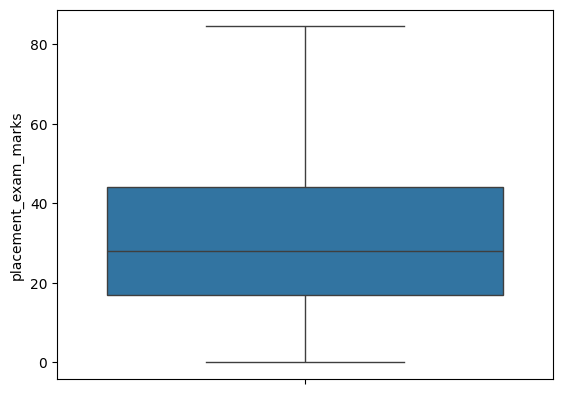

In [70]:
sns.boxplot(df_capping['placement_exam_marks'])

/tmp/ipykernel_6078/37629288.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
/tmp/ipykernel_6078/37629288.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_capping['placement_exam_marks'])


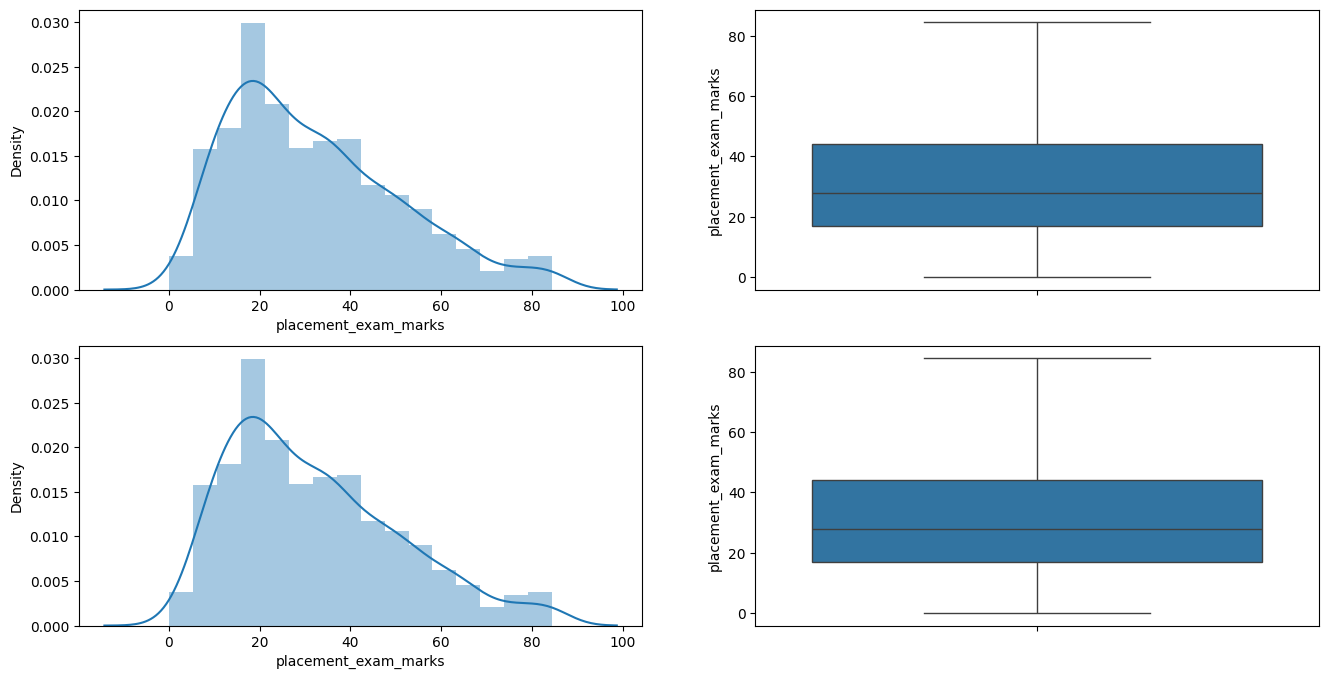

In [72]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.distplot(df_capping['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(df_capping['placement_exam_marks'])

plt.show()